In [1]:
import pandas as pd 
import numpy as np 
import joblib
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
from boruta import BorutaPy
from sklearn.feature_selection import mutual_info_classif,SelectKBest,mutual_info_regression
from sklearn.ensemble import RandomForestClassifier,IsolationForest
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,make_scorer, classification_report,average_precision_score,precision_recall_curve, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")
from optbinning import OptimalBinning
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math
from statsmodels.api import add_constant
from sklearn.linear_model import LogisticRegression
import optuna
from sklearn.model_selection import cross_val_score


In [2]:
# Read Data from csv
# df1 = pd.read_csv(r"C:\Users\rkade\Downloads\Case Study\dataset.csv",delimiter = "|")

df1 = pd.read_csv("dataset.csv", sep = '|')
df = df1.copy()
df.head()

,Feature_ae_0,Feature_dn_1,Feature_cn_2,Feature_ps_3,Feature_ps_4,Feature_ee_5,Feature_cx_6,Feature_cx_7,Feature_em_8,Feature_nd_9,...,Feature_md_11,Feature_ed_12,Feature_dd_13,Feature_hd_14,Feature_ld_15,Feature_cd_16,Feature_md_17,Feature_dd_18,Feature_pd_19,Response
0,57,371,1,999,1,-1.8,92.893,-46.2,1.299,5099.1,...,Cat_1_m***d,Cat_3_h***l,Cat_0_n***o,Cat_0_n***o,Cat_2_y***s,Cat_0_c***r,Cat_6_m***y,Cat_1_m***n,Cat_0_f***e,0
1,55,285,2,999,0,1.1,93.994,-36.4,4.860,5191.0,...,Cat_1_m***d,Cat_7_u***n,Cat_1_u***n,Cat_2_y***s,Cat_0_n***o,Cat_1_t***e,Cat_6_m***y,Cat_2_t***u,Cat_1_n***t,0
2,33,52,1,999,1,-1.8,92.893,-46.2,1.313,5099.1,...,Cat_1_m***d,Cat_2_b***y,Cat_0_n***o,Cat_0_n***o,Cat_0_n***o,Cat_0_c***r,Cat_6_m***y,Cat_0_f***i,Cat_0_f***e,0
3,36,355,4,999,0,1.4,94.465,-41.8,4.967,5228.1,...,Cat_1_m***d,Cat_3_h***l,Cat_0_n***o,Cat_0_n***o,Cat_0_n***o,Cat_1_t***e,Cat_4_j***n,Cat_0_f***i,Cat_1_n***t,0
4,27,189,2,999,0,1.4,93.918,-42.7,4.963,5228.1,...,Cat_1_m***d,Cat_3_h***l,Cat_0_n***o,Cat_2_y***s,Cat_0_n***o,Cat_0_c***r,Cat_3_j***l,Cat_0_f***i,Cat_1_n***t,0


In [3]:
df = df.drop_duplicates()

In [4]:
df.shape

(34989, 21)

# EDA

In [5]:
# checking data types of features
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34989 entries, 0 to 34999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Feature_ae_0   34989 non-null  int64  
 1   Feature_dn_1   34989 non-null  int64  
 2   Feature_cn_2   34989 non-null  int64  
 3   Feature_ps_3   34989 non-null  int64  
 4   Feature_ps_4   34989 non-null  int64  
 5   Feature_ee_5   34989 non-null  float64
 6   Feature_cx_6   34989 non-null  float64
 7   Feature_cx_7   34989 non-null  float64
 8   Feature_em_8   34989 non-null  float64
 9   Feature_nd_9   34989 non-null  float64
 10  Feature_jd_10  34989 non-null  object 
 11  Feature_md_11  34989 non-null  object 
 12  Feature_ed_12  34989 non-null  object 
 13  Feature_dd_13  34989 non-null  object 
 14  Feature_hd_14  34989 non-null  object 
 15  Feature_ld_15  34989 non-null  object 
 16  Feature_cd_16  34989 non-null  object 
 17  Feature_md_17  34989 non-null  object 
 18  Feature_dd_


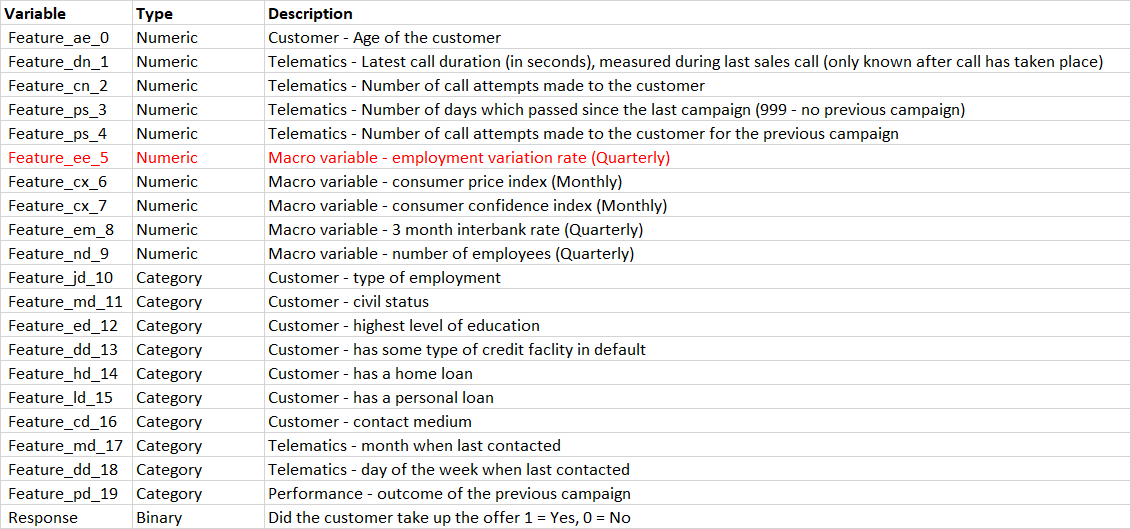

In [6]:
# checking nulls
df.isna().sum()

Feature_ae_0     0
Feature_dn_1     0
Feature_cn_2     0
Feature_ps_3     0
Feature_ps_4     0
Feature_ee_5     0
Feature_cx_6     0
Feature_cx_7     0
Feature_em_8     0
Feature_nd_9     0
Feature_jd_10    0
Feature_md_11    0
Feature_ed_12    0
Feature_dd_13    0
Feature_hd_14    0
Feature_ld_15    0
Feature_cd_16    0
Feature_md_17    0
Feature_dd_18    0
Feature_pd_19    0
Response         0
dtype: int64

In [7]:
# Checking the Response Rate
round(100*df[df['Response']==1].shape[0]/df.shape[0],2)


11.23

### 11% response rate shows that there is class imbalance present, but is within normal range because this is representative of real world data.However it is important to know because this influences the hyperparameter tuning,model selection and evaluation metric

In [8]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
response = 'Response'

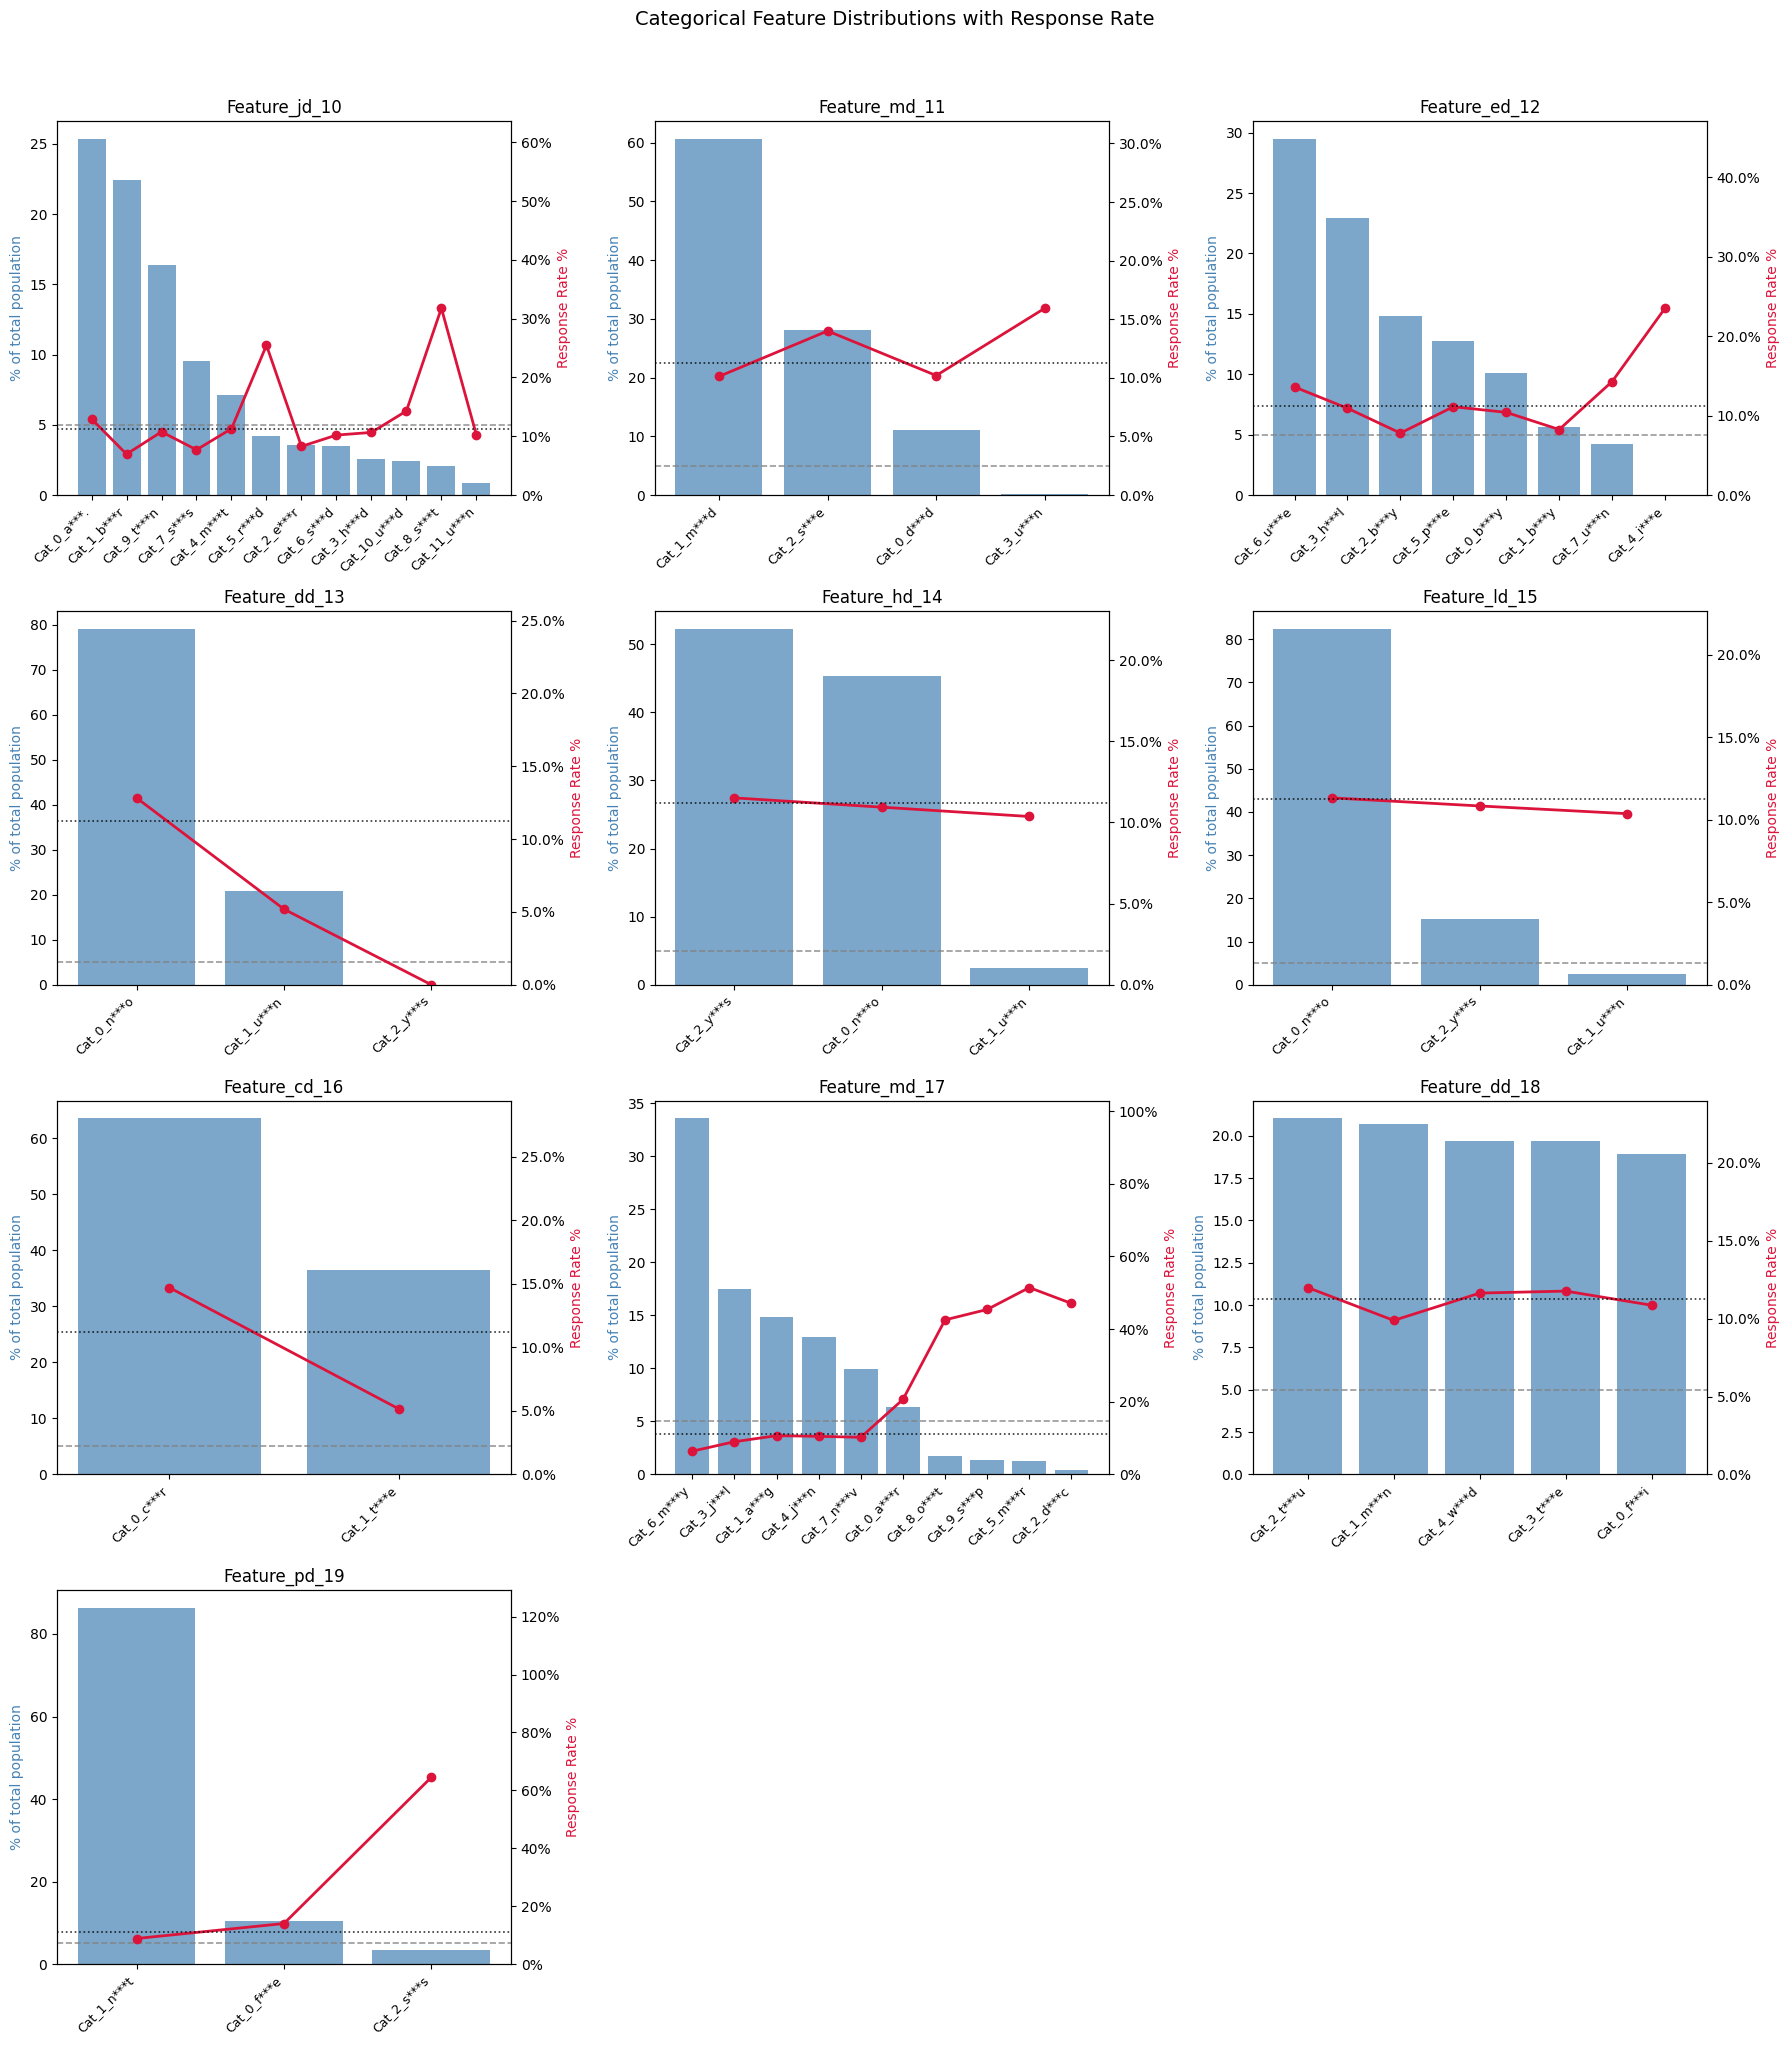

In [9]:
# Grid layout
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

tot_records = len(df)

for i, col in enumerate(cat_cols):
    ax1 = axes[i]
    
    # Count per category
    counts = df[col].value_counts()

    #percent of total population
    cnt_pct = (counts/tot_records)*100
    
    # Response rate per category
    response_rate = df.groupby(col)[response].mean() * 100
    response_rate = response_rate.reindex(counts.index)
    
    # Bar chart — frequency
    bars = ax1.bar(range(len(cnt_pct)), cnt_pct.values, 
                   color='steelblue', alpha=0.7, label='Count')
    ax1.set_xticks(range(len(cnt_pct)))
    ax1.set_xticklabels(cnt_pct.index, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('% of total population', color='steelblue')
    ax1.set_title(col)
    ax1.axhline(y=5.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.8, 
                label='5% Vol Floor')
    
    # Overlay response rate on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(range(len(cnt_pct)), response_rate.values, 
             color='crimson', marker='o', linewidth=2, label='Response Rate')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_ylabel('Response Rate %', color='crimson')
    ax2.set_ylim(0, response_rate.max() * 2)
    ax2.axhline(y=11.23, color='black', linestyle='dotted', linewidth=1.2, alpha=0.8, 
                label='sample response rate')
    

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions with Response Rate', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('categorical_eda.png', dpi=150, bbox_inches='tight')
plt.show()

Feature_dd_18, Feature_hd_14, Feature_ld_15 -> flat lines no risk differentiation at characteristic level. No point of using this in the model  

In [10]:
# clean up of categorical variables

def apply_custom_categorical_cleanup(df_input):
    """
    Applies strategic pre-modeling categorical cleaning transformations 
    based on exploratory data analysis (EDA) insights.
    """
    # Create a deep copy to preserve the original raw dataframe
    df_clean = df_input.copy()
    
    # -------------------------------------------------------------------------
    # ACTION 1: Drop uninformative variables (Flat trends / Zero predictive power)
    # -------------------------------------------------------------------------
    drop_cols = ['Feature_dd_18', 'Feature_hd_14', 'Feature_ld_15']
    df_clean.drop(columns=drop_cols, errors='ignore', inplace=True)
    
    # [ACTION 2 Note]: 'Feature_cd_16' and 'Feature_pd_19' are preserved implicitly 
    # by leaving them untouched in the dataframe for downstream One-Hot Encoding.
    
    # -------------------------------------------------------------------------
    # ACTION 3: Merge sparse low-volume tails (< 5% population) into an 'Other' bucket
    # -------------------------------------------------------------------------
    # Feature_md_17 (Contact Month): Group tiny tail months
    # Keeps high-volume months standalone, groups sparse, volatile ones
    md_17_keep = ['Cat_6_m***y', 'Cat_3_j***l', 'Cat_1_a***g', 'Cat_4_j***n', 'Cat_7_n***v', 'Cat_0_a***r']
    df_clean['Feature_md_17'] = df_clean['Feature_md_17'].apply(
        lambda x: x if x in md_17_keep else 'High_Yield_Tail'
    )
    
    # Feature_jd_10 (Employment Type): Group low-frequency occupations
    jd_10_keep = ['Cat_0_a***', 'Cat_1_b***', 'Cat_9_t***', 'Cat_7_s***', 'Cat_4_m***']
    df_clean['Feature_jd_10'] = df_clean['Feature_jd_10'].apply(
        lambda x: x if x in jd_10_keep else 'Other_Occupations'
    )
    
    # -------------------------------------------------------------------------
    # ACTION 4: Merge specific categories explicitly
    # -------------------------------------------------------------------------
    # Feature_dd_13: Merge sparse Cat_2 into Cat_1
    if 'Feature_dd_13' in df_clean.columns:
        df_clean['Feature_dd_13'] = df_clean['Feature_dd_13'].replace('Cat_2_y***s', 'Cat_1_u***n')
        
    # Feature_md_11: Merge minor group Cat_0 and sparse Cat_3
    if 'Feature_md_11' in df_clean.columns:
        df_clean['Feature_md_11'] = df_clean['Feature_md_11'].replace('Cat_3_u***n', 'Cat_0_d***d')

    # -------------------------------------------------------------------------
    # ACTION 5: Isolate specific high-signal category
    # -------------------------------------------------------------------------
    # Feature_ed_12: Group everything except Cat_4 to preserve its distinct positive swing
    if 'Feature_ed_12' in df_clean.columns:
        # Map to isolate Cat_4, grouping other sparse or uniform levels safely
        df_clean['Feature_ed_12'] = df_clean['Feature_ed_12'].apply(
            lambda x: 'Cat_4_j***e' if x == 'Cat_4_j***e' else ('Cat_6_u***', 'Cat_3_h***', 'Cat_2_b***' if x in ['Cat_6_u***', 'Cat_3_h***', 'Cat_2_b***'] else 'Other_Education')
        )
        
    return df_clean

# =============================================================================
# PRODUCTION EXECUTION PIPELINE
# =============================================================================
# Run the cleanup sequence independently across your stratified train/test boundaries:
# X_train_clean = apply_custom_categorical_cleanup(X_train)
# X_val_clean   = apply_custom_categorical_cleanup(X_val)
# X_test_clean  = apply_custom_categorical_cleanup(X_test)

df_test = apply_custom_categorical_cleanup(df)
# Verify the feature dimensional reduction
print("=== Categorical Optimization Verification ===")
print(f"Original Training Features Shape: {df.shape}")
print(f"Optimized Training Features Shape: {df_test.shape}")


=== Categorical Optimization Verification ===
Original Training Features Shape: (34989, 21)
Optimized Training Features Shape: (34989, 18)


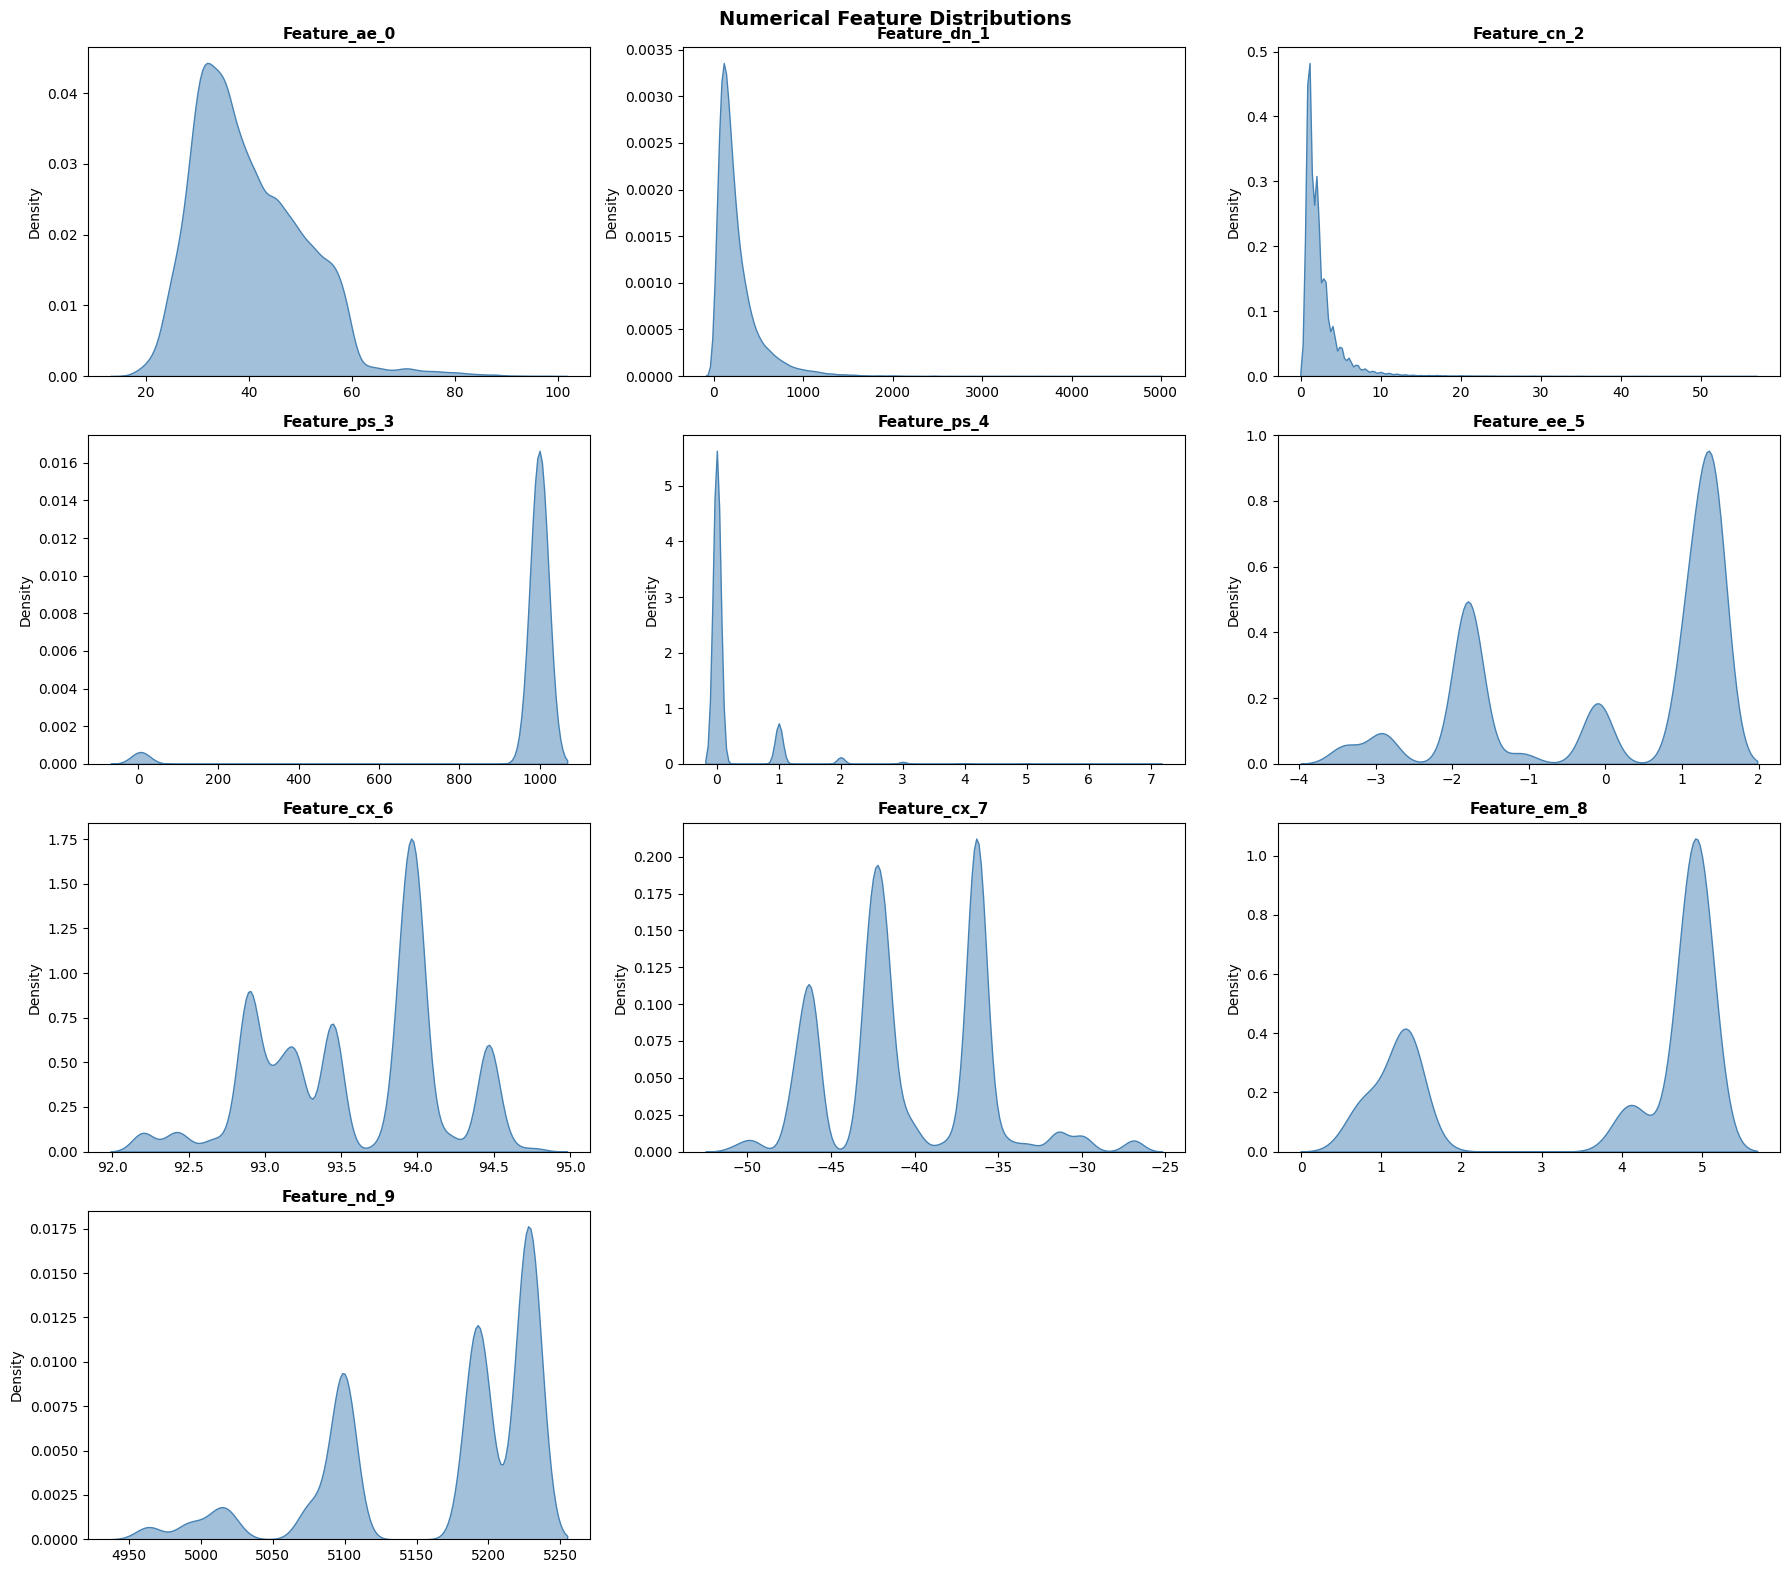

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != 'Response']

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(df[col].dropna(), ax=axes[i], 
                fill=True, color='steelblue', alpha=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_kde.png', dpi=150, bbox_inches='tight')
plt.show()

=== Numerical Outlier Treatment Report ===
-> Feature_ae_0: Found 401 outliers. Capped to 1st Pctl (23.0) and 95th Pctl (58.0)
-> Feature_dn_1: Found 2534 outliers. Capped to 1st Pctl (11.0) and 95th Pctl (750.0)
-> Feature_cn_2: Found 2036 outliers. Capped to 1st Pctl (1.0) and 95th Pctl (7.0)
-> Feature_ps_3: Found 1289 rows outside whiskers. (Skipping capping; handled via 999 flag later)
-> Feature_ps_4: Found 4808 outliers. Capped to 1st Pctl (0.0) and 95th Pctl (1.0)
=== Outlier Treatment Verification ===


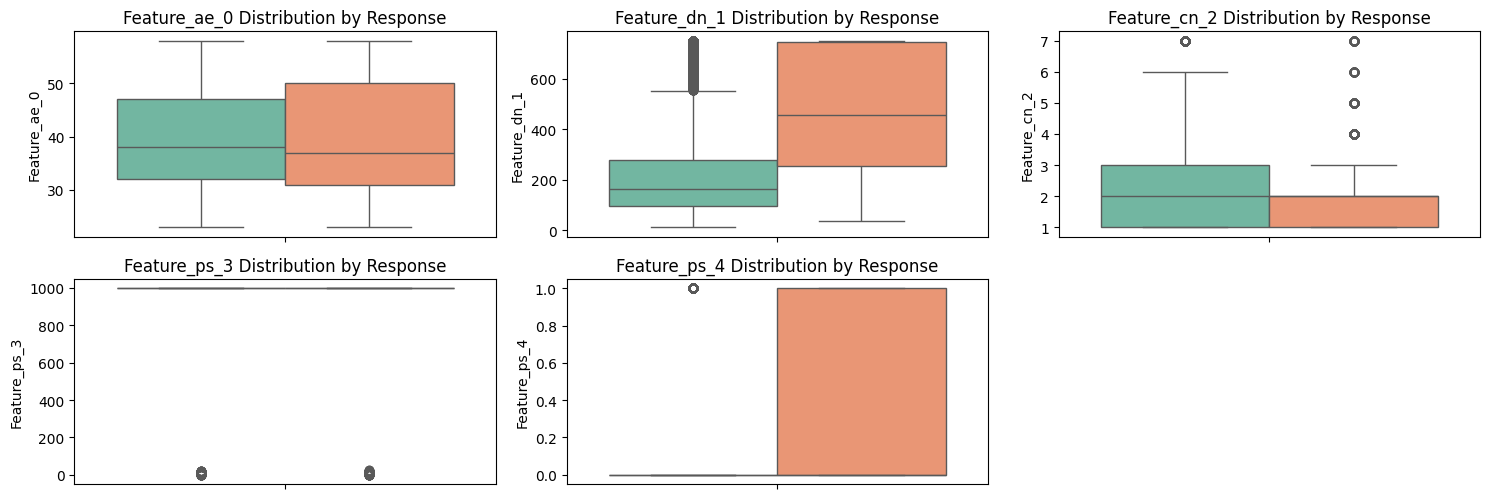

In [12]:
# outlier treatment of numerical variables
def treat_numerical_outliers(df_input, operational_cols):
    """
    Detects if outliers exist using IQR and caps them at 1st/99th percentiles
    to stabilize variance before checking response trends.
    """
    df_clean = df_input.copy()
    
    print("=== Numerical Outlier Treatment Report ===")
    for col in operational_cols:
        if col not in df_clean.columns:
            continue
            
        # 1. Statistical Check using IQR Rule
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_whisker = Q1 - 1.5 * IQR
        upper_whisker = Q3 + 1.5 * IQR
        
        # Count how many records fall outside the whiskers
        outliers_count = ((df_clean[col] < lower_whisker) | (df_clean[col] > upper_whisker)).sum()
        
        # 2. Outlier Capping (Winsorization) if outliers are found
        if outliers_count > 0:
            lower_bound = df_clean[col].quantile(0.01)
            upper_bound = df_clean[col].quantile(0.95)
            
            # Special bypass for Feature_ps_3 to avoid corrupting the 999 indicator flag
            if col == 'Feature_ps_3':
                print(f"-> {col:<12}: Found {outliers_count} rows outside whiskers. (Skipping capping; handled via 999 flag later)")
                continue
                
            df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
            print(f"-> {col:<12}: Found {outliers_count} outliers. Capped to 1st Pctl ({lower_bound:.1f}) and 95th Pctl ({upper_bound:.1f})")
        else:
            print(f"-> {col:<12}: Clean. No outliers detected.")
            
    return df_clean

# List of operational continuous features identified from your boxplots
operational_features = ['Feature_ae_0', 'Feature_dn_1', 'Feature_cn_2', 'Feature_ps_3', 'Feature_ps_4']

# Run the pipeline on your dataset
df_numerical_clean = treat_numerical_outliers(df_test, operational_features)

# Verify the feature dimensional reduction
print("=== Outlier Treatment Verification ===")
plt.figure(figsize=(15, 10))
for i, col in enumerate(operational_features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=df_numerical_clean, hue='Response', y=col, palette='Set2',legend = False)
    plt.title(f'{col} Distribution by Response')

plt.tight_layout()
plt.show()

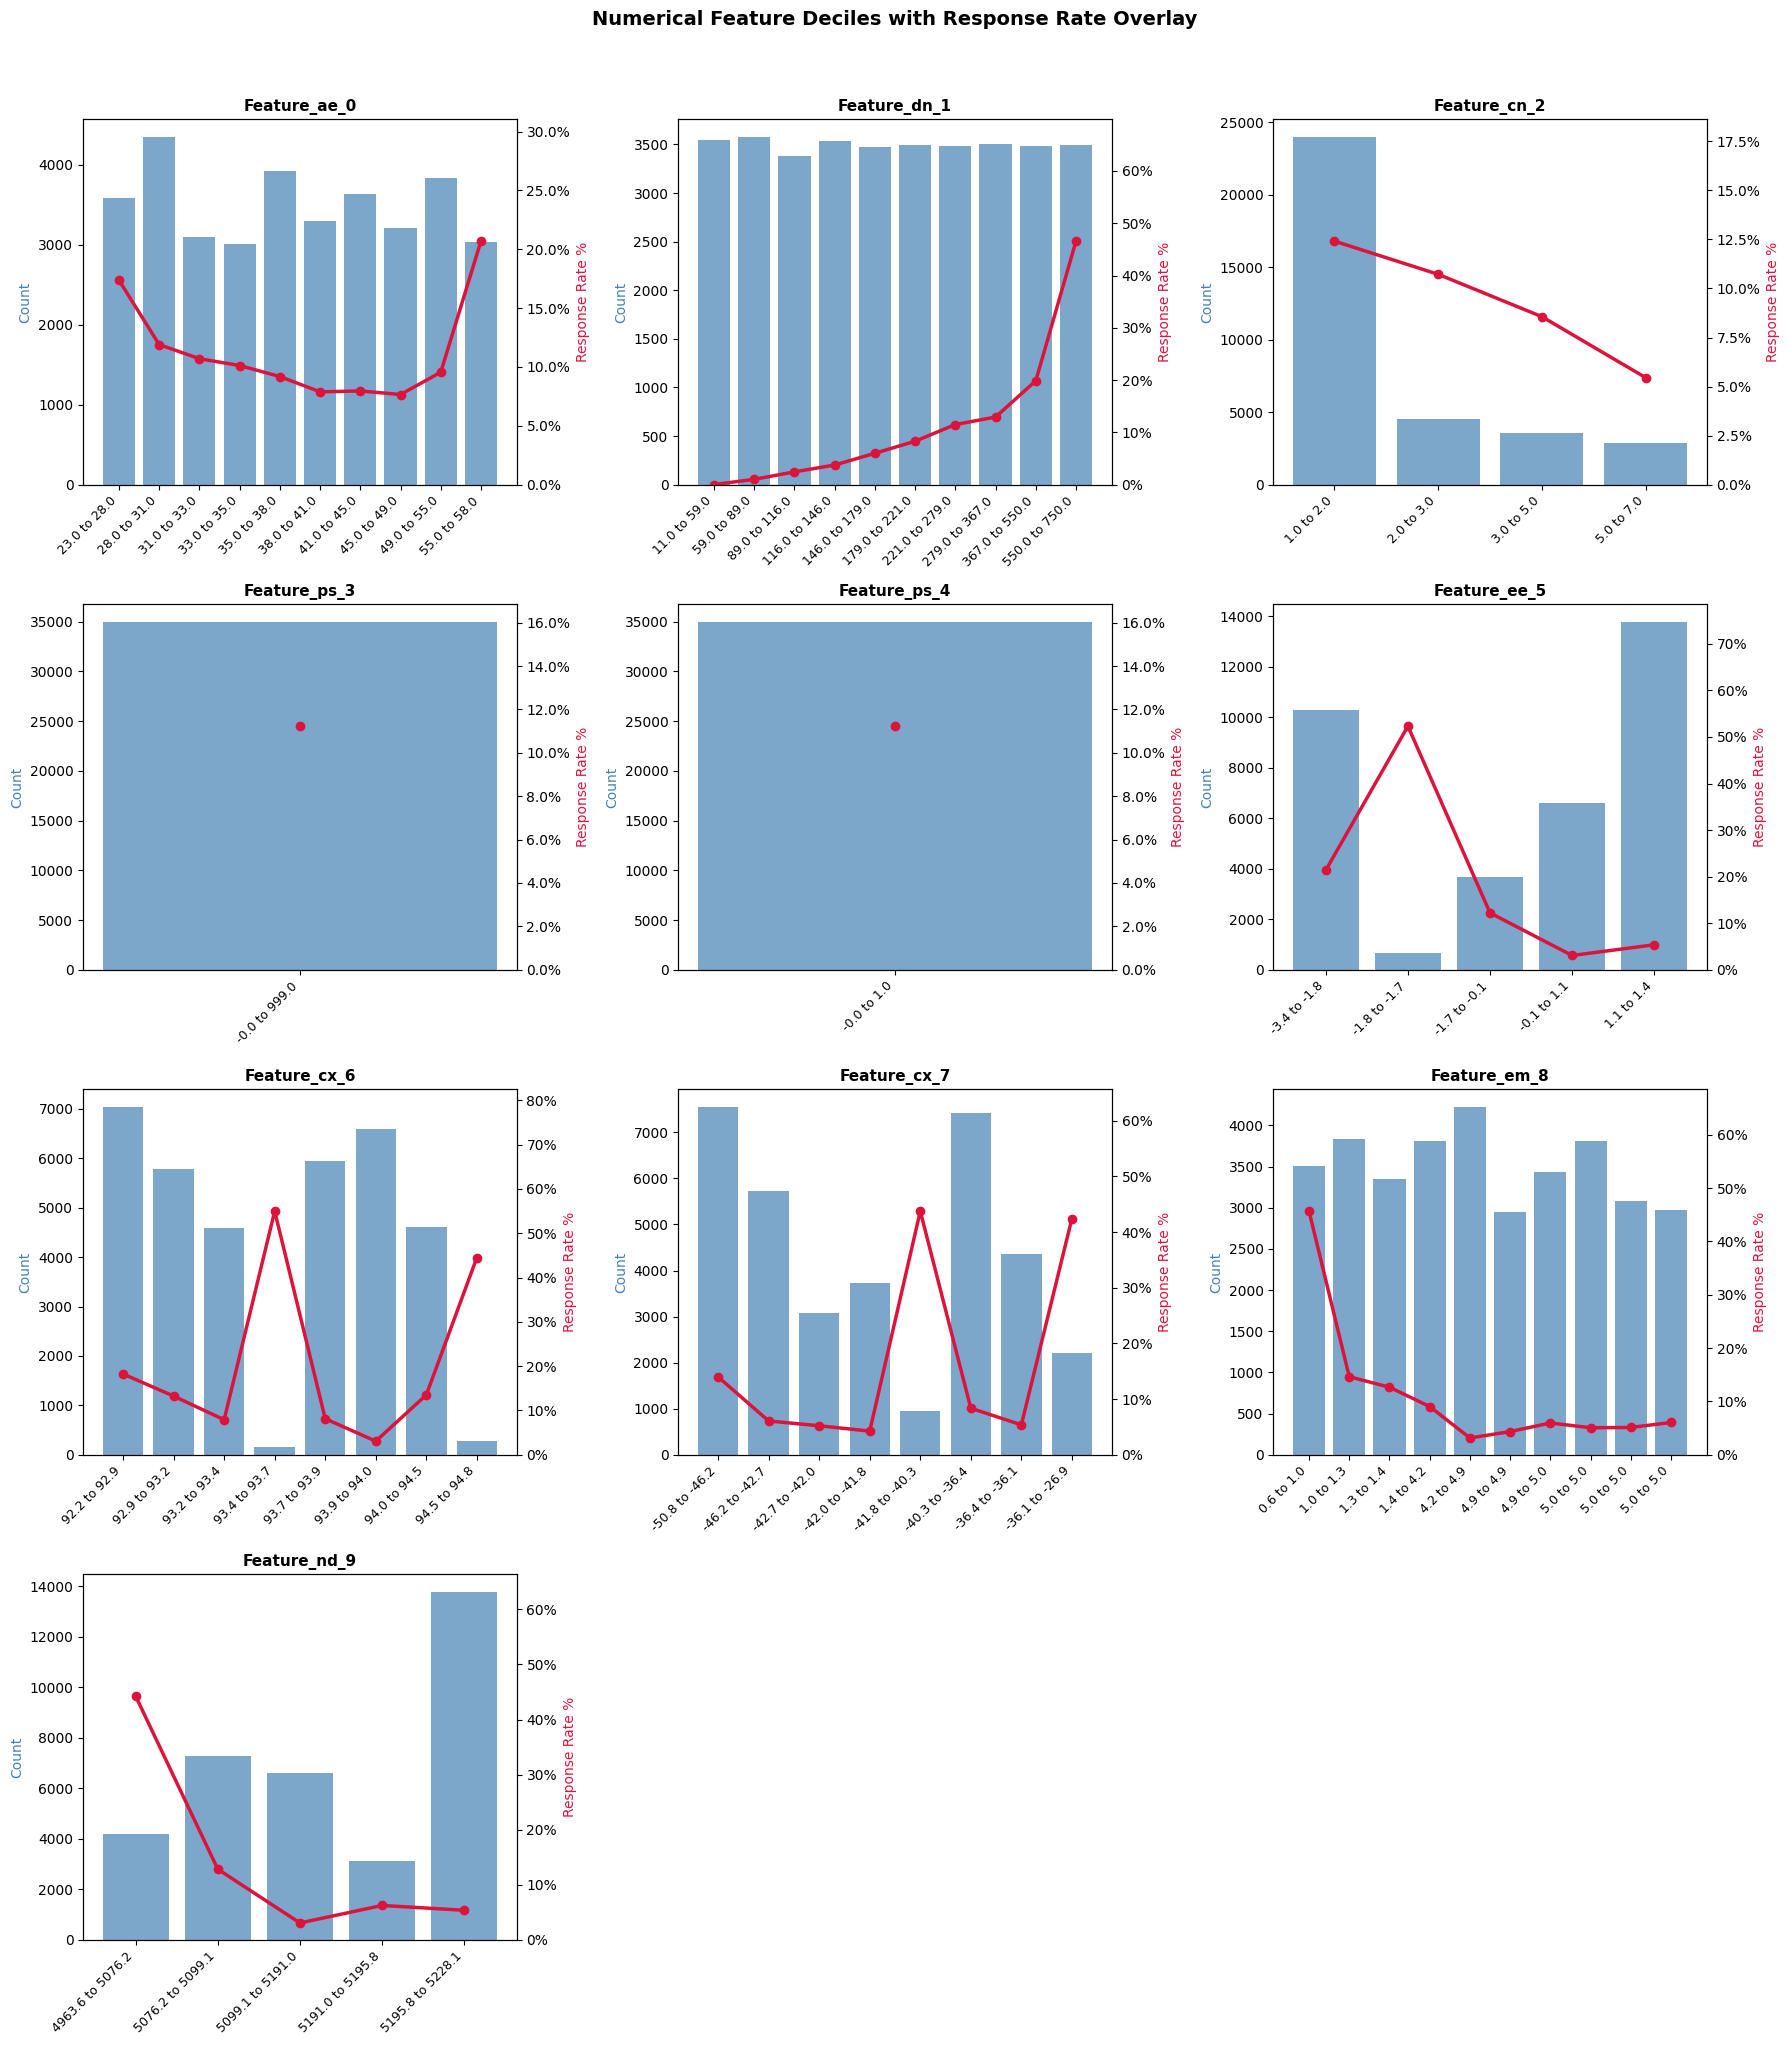

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

num_cols = df_numerical_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != 'Response']

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax1 = axes[i]
    
    # 1. Bin the continuous data into Deciles (10 buckets)
    # dropna() ensures we don't break the math, duplicates='drop' handles columns with heavy zero-inflation
    temp_df = df_numerical_clean[[col, 'Response']].dropna().copy()
    temp_df['Bin'] = pd.qcut(temp_df[col], q=10, duplicates='drop')
    
    # 2. Calculate count and response rate per bin
    agg_df = temp_df.groupby('Bin', observed=True)['Response'].agg(['count', 'mean']).reset_index()
    
    # 3. Format X-axis labels nicely
    x_labels = [f"{interval.left:.1f} to {interval.right:.1f}" for interval in agg_df['Bin']]
    x_pos = np.arange(len(agg_df))
    
    # 4. Bar chart — Frequency / Volume
    ax1.bar(x_pos, agg_df['count'], color='steelblue', alpha=0.7, label='Count')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Count', color='steelblue')
    ax1.set_title(col, fontsize=11, fontweight='bold')
    
    # 5. Overlay Response Rate on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(x_pos, agg_df['mean'] * 100, color='crimson', marker='o', linewidth=2.5, label='Response Rate')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_ylabel('Response Rate %', color='crimson')
    
    # Ensure the line chart scales nicely above the bars
    ax2.set_ylim(0, max(agg_df['mean'] * 100) * 1.5)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Deciles with Response Rate Overlay', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('numerical_response_rate_bins.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
X = df_numerical_clean.drop(columns = 'Response')
y = df_numerical_clean['Response']

# 2. Step 1: Split into Train (70%) and a Temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y  # Maintains the 11.23% response rate balance
)

# 3. Step 2: Split the Temporary set equally into Test (15%) and Validation (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp  # Maintains balance in sub-splits
)

# 4. Print dataset shapes to verify sizes
print("=== Dataset Split Summary ===")
print(f"Train Set      : {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.1f}%) | Response Rate: {y_train.mean()*100:.2f}%")
print(f"Validation Set : {X_val.shape[0]} rows ({X_val.shape[0]/len(df)*100:.1f}%) | Response Rate: {y_val.mean()*100:.2f}%")
print(f"Test Set       : {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.1f}%) | Response Rate: {y_test.mean()*100:.2f}%")


=== Dataset Split Summary ===
Train Set      : 24492 rows (70.0%) | Response Rate: 11.23%
Validation Set : 5248 rows (15.0%) | Response Rate: 11.22%
Test Set       : 5249 rows (15.0%) | Response Rate: 11.24%


In [15]:
def compute_variable_iv(dataframe, response, feature, target='Response', bins=5):
    """Computes IV for both numeric (via binning) and categorical features."""
    # df_temp = dataframe[[feature, target]].copy().dropna()

    df_temp = pd.concat([dataframe, response], axis=1).dropna()

    
    # Check if variable is numerical or categorical
    if df_temp[feature].dtype in [np.number, 'int64', 'float64']:
        # Use qcut for continuous features; fall back to standard cut if qcut fails due to low variance
        try:
            df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop').astype(str)
        except ValueError:
            df_temp['bin'] = pd.cut(df_temp[feature], bins=bins, duplicates='drop').astype(str)
    else:
        df_temp['bin'] = df_temp[feature].astype(str)
        
    # Aggregate counts of events (1) and non-events (0)
    summary = df_temp.groupby('bin')[target].agg(['count', 'sum'])
    summary.columns = ['Total', 'Events']
    summary['Non_Events'] = summary['Total'] - summary['Events']
    
    total_events = summary['Events'].sum()
    total_non_events = summary['Non_Events'].sum()
    
    # Edge case protection for divisions/logs
    if total_events == 0 or total_non_events == 0:
        return 0.0
        
    summary['Dist_Event'] = summary['Events'] / total_events
    summary['Dist_Non_Event'] = summary['Non_Events'] / total_non_events
    
    # Replace exact zeroes with a micro-epsilon to prevent log(0) or division errors
    summary['Dist_Event'] = summary['Dist_Event'].replace(0, 0.0001)
    summary['Dist_Non_Event'] = summary['Dist_Non_Event'].replace(0, 0.0001)
    
    # Calculate WoE and IV
    summary['WoE'] = np.log(summary['Dist_Event'] / summary['Dist_Non_Event'])
    summary['IV_Contribution'] = (summary['Dist_Event'] - summary['Dist_Non_Event']) * summary['WoE']
    
    return summary['IV_Contribution'].sum()

def categorize_iv(iv_value):
    """Categorizes IV score into predictive power bins."""
    if iv_value < 0.02:
        return "Useless for prediction"
    elif 0.02 <= iv_value < 0.1:
        return "Weak predictive power"
    elif 0.1 <= iv_value < 0.3:
        return "Medium predictive power"
    elif 0.3 <= iv_value <= 0.5:
        return "Strong predictive power"
    else:
        return "Suspiciously high (Check for target leakage)"

# List of features exactly matching your image
features_list = X_train.columns.tolist()

# Run loop and collect results
iv_results = []
for col in features_list:
    if col in df.columns:
        score = compute_variable_iv(X_train, y_train, col)
        status = categorize_iv(score)
        iv_results.append({'Variable': col, 'IV_Score': round(score, 4), 'Predictive_Power': status})

# Convert to DataFrame and sort descending by score
iv_df = pd.DataFrame(iv_results).sort_values(by='IV_Score', ascending=False).reset_index(drop=True)

# Print the clean summary report
print("\n=== INFORMATION VALUE (IV) SUMMARY REPORT ===")
print(iv_df.to_string(index=False))


=== INFORMATION VALUE (IV) SUMMARY REPORT ===
     Variable  IV_Score                             Predictive_Power
 Feature_dn_1    1.6183 Suspiciously high (Check for target leakage)
 Feature_nd_9    0.7882 Suspiciously high (Check for target leakage)
 Feature_em_8    0.7739 Suspiciously high (Check for target leakage)
 Feature_ee_5    0.6285 Suspiciously high (Check for target leakage)
Feature_pd_19    0.5430 Suspiciously high (Check for target leakage)
Feature_md_17    0.4732                      Strong predictive power
 Feature_cx_6    0.3531                      Strong predictive power
Feature_cd_16    0.2412                      Medium predictive power
 Feature_cx_7    0.1923                      Medium predictive power
Feature_dd_13    0.1302                      Medium predictive power
 Feature_ae_0    0.0765                        Weak predictive power
 Feature_cn_2    0.0483                        Weak predictive power
Feature_md_11    0.0313                        Weak pred

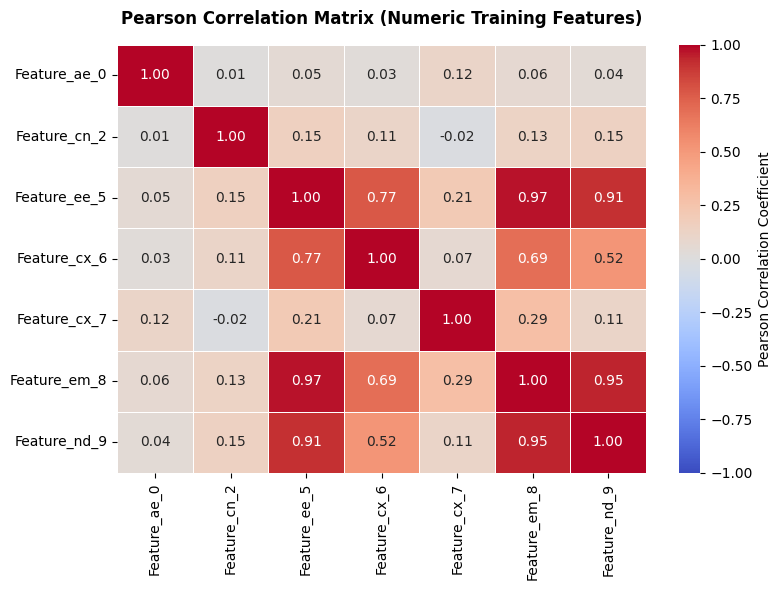

In [16]:
features_list = X_train.columns.tolist()

# 1. Define the definitive drop list based on your IV report
useless_features = ['Feature_ps_3', 'Feature_ps_4', 'Feature_ed_12', 'Feature_jd_10']
leaking_features = ['Feature_dn_1']

drop_list = useless_features + leaking_features

import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(X_dataframe, numeric_columns):
    """
    Computes and plots a Pearson correlation heatmap for numeric features.
    """
    # 1. Compute the linear correlation matrix (-1 to 1 scale)
    corr_matrix = X_dataframe[numeric_columns].corr(method='pearson')
    
    # 2. Setup the matplotlib figure size
    plt.figure(figsize=(8, 6))
    
    # 3. Create the heatmap with a diverging color palette
    sns.heatmap(
        corr_matrix, 
        annot=True,             # Shows numerical correlation values inside squares
        fmt=".2f",              # Limits decimal points to 2
        cmap='coolwarm',        # Red = Positive correlation, Blue = Negative correlation
        vmin=-1, vmax=1,        # Sets absolute anchors for the color bar
        linewidths=0.5,         # Adds clean borders between grid boxes
        cbar_kws={"label": "Pearson Correlation Coefficient"}
    )
    
    plt.title("Pearson Correlation Matrix (Numeric Training Features)", fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

# The correct way using list comprehension
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
active_cols = [col for col in num_cols if col not in drop_list]

# Generate the plot
plot_correlation_matrix(X_train, active_cols)


These variables are your macroeconomic indicators, and their extreme cross-correlation (up to 0.97) will destabilize your linear baseline model if left untreated.


Feature_ee_5: Employment variation rate (Quarterly)

Feature_cx_6: Consumer price index / Inflation (Monthly)

Feature_em_8: 3-month interbank interest rate (Quarterly)

Feature_nd_9: Number of employees in the economy (Quarterly)


Feature_nd_9 (Keep): IV = 0.7882 (Highest predictive power)

Feature_em_8 (Drop): IV = 0.7739

Feature_ee_5 (Drop): IV = 0.6285

Feature_cx_6 (Drop): IV = 0.3531


In [17]:
corr_macro_vars = ['Feature_em_8', 'Feature_ee_5', 'Feature_cx_6']
drop_list_upd = drop_list + corr_macro_vars

# 2. Drop from X_train (Apply the same to X_val and X_test to keep them aligned)
X_train_selected = X_train.drop(columns=drop_list_upd, errors='ignore')
X_val_selected   = X_val.drop(columns=drop_list_upd, errors='ignore')
X_test_selected  = X_test.drop(columns=drop_list_upd, errors='ignore')

print("=== Feature Selection Complete ===")
print(f"Dropped {len(drop_list_upd)} features: {drop_list_upd}")
print(f"Remaining active features for modeling: {X_train_selected.shape[1]}")
print(list(X_train_selected.columns))

=== Feature Selection Complete ===
Dropped 8 features: ['Feature_ps_3', 'Feature_ps_4', 'Feature_ed_12', 'Feature_jd_10', 'Feature_dn_1', 'Feature_em_8', 'Feature_ee_5', 'Feature_cx_6']
Remaining active features for modeling: 9
['Feature_ae_0', 'Feature_cn_2', 'Feature_cx_7', 'Feature_nd_9', 'Feature_md_11', 'Feature_dd_13', 'Feature_cd_16', 'Feature_md_17', 'Feature_pd_19']


In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_multicollinearity(X_dataframe, numeric_columns):
    """
    Calculates Variance Inflation Factor (VIF) for specified numeric features.
    """
    # Isolate only the numeric features to test
    X_numeric = X_dataframe[numeric_columns].copy()
    
    # Drop rows with missing values for the calculation if any remain
    X_numeric = X_numeric.dropna()
    
    # VIF requires a constant/intercept column to calculate correctly
    X_numeric['Intercept'] = 1.0
    
    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Variable"] = numeric_columns
    vif_data["VIF_Score"] = [
        variance_inflation_factor(X_numeric.values, i) 
        for i in range(len(numeric_columns))
    ]
    
    # Round results for cleaner reading and sort descending
    vif_data["VIF_Score"] = vif_data["VIF_Score"].round(2)
    vif_data = vif_data.sort_values(by="VIF_Score", ascending=False).reset_index(drop=True)
    
    return vif_data

# Define the numerical features currently in your active 9-variable pool
active_num_cols = X_train_selected.select_dtypes(include=[np.number]).columns.tolist()

# Run the function on your training slice
vif_report = check_multicollinearity(X_train_selected, active_num_cols)

print("=== VARIANCE INFLATION FACTOR (VIF) REPORT ===")
print(vif_report)

=== VARIANCE INFLATION FACTOR (VIF) REPORT ===
       Variable  VIF_Score
0  Feature_nd_9       1.04
1  Feature_cx_7       1.03
2  Feature_cn_2       1.02
3  Feature_ae_0       1.01


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 1. Separate your 9 active features by their data types
num_cols = ['Feature_ae_0', 'Feature_cn_2', 'Feature_cx_7', 'Feature_nd_9']
cat_cols = ['Feature_md_11', 'Feature_dd_13', 'Feature_cd_16', 'Feature_md_17', 'Feature_pd_19']
active_cols = num_cols + cat_cols

# 2. Build the structural preprocessor transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), num_cols),
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# 3. Fit the transformer on your Training features, then transform all splits safely
X_train_proc = preprocessor.fit_transform(X_train[active_cols])
X_val_proc   = preprocessor.transform(X_val[active_cols])
X_test_proc  = preprocessor.transform(X_test[active_cols])

In [20]:
import math
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, classification_report

# ── 1. Convert Proc Arrays back to Pandas DataFrames (THE MISSING STEP) ────────
feature_names = preprocessor.get_feature_names_out()

X_train_proc_df = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_val_proc_df   = pd.DataFrame(X_val_proc, columns=feature_names, index=X_val.index)
X_test_proc_df  = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

# ── 2. Fit statsmodels LR for p-values ────────────────────────────────────────
X_const = sm.add_constant(X_train_proc_df)
sm_lr   = sm.Logit(y_train, X_const).fit(disp=False)

print("=== STATSMODELS SUMMARY ===")
print(sm_lr.summary2())

# ── 3. Extract feature significance ──────────────────────────────────────────────
# slice from [1:] to skip the 'const' row added by add_constant
coef_df = pd.DataFrame({
    'Coefficient' : sm_lr.params[1:],
    'P-Value'     : sm_lr.pvalues[1:],
    'Significant' : sm_lr.pvalues[1:] < 0.05
}).sort_values('P-Value')

print("\n── Feature Selection Summary ───────────────────────────────")
print(coef_df.to_string())

# ── 4. Drop insignificant features ───────────────────────────────────────────────
insignificant = coef_df[~coef_df['Significant']].index.tolist()
final_features = [f for f in X_train_proc_df.columns if f not in insignificant]

print(f"\n── Insignificant features (p > 0.05) : {insignificant}")
print(f"── Features dropped  : {len(insignificant)}")
print(f"── Features retained : {len(final_features)}")
print(f"── Final features    : {final_features}")

# This will now work perfectly since we are indexing clean DataFrames!
X_train_final = X_train_proc_df[final_features]
X_val_final   = X_val_proc_df[final_features]
X_test_final  = X_test_proc_df[final_features]

# ── 5. Vanilla LR baseline on final features ────────────────────────────────────
vanilla_lr = LogisticRegression(random_state=42, max_iter=1000)
vanilla_lr.fit(X_train_final, y_train)

y_pred = vanilla_lr.predict(X_val_final)
y_prob = vanilla_lr.predict_proba(X_val_final)[:, 1]

print("\n── Vanilla LR Baseline (post feature selection) ────────────")
print(f"── Average Precision : {average_precision_score(y_val, y_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_pred))


=== STATSMODELS SUMMARY ===
                                      Results: Logit
Model:                        Logit                    Method:                   MLE       
Dependent Variable:           Response                 Pseudo R-squared:         0.197     
Date:                         2026-05-23 18:55         AIC:                      13849.0920
No. Observations:             24492                    BIC:                      13986.8958
Df Model:                     16                       Log-Likelihood:           -6907.5   
Df Residuals:                 24475                    LL-Null:                  -8603.0   
Converged:                    1.0000                   LLR p-value:              0.0000    
No. Iterations:               7.0000                   Scale:                    1.0000    
-------------------------------------------------------------------------------------------
                                            Coef.  Std.Err.    z     P>|z|   [0.025  0.975]

In [21]:
# ── Balanced LR model on your 10 statistically significant features ────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Dynamic weight alignment via class_weight='balanced'
balanced_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
balanced_lr.fit(X_train_final, y_train)

# Generate predictions and raw probability distributions on your validation sets
y_pred_bal = balanced_lr.predict(X_val_final)
y_prob_bal = balanced_lr.predict_proba(X_val_final)[:, 1]

print("── Balanced LR Post Feature Selection (Validation Set) ────")
print(f"── ROC-AUC Score       : {roc_auc_score(y_val, y_prob_bal):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_bal))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_bal))

── Balanced LR Post Feature Selection (Validation Set) ────
── ROC-AUC Score       : 0.7886

Confusion Matrix:
[[4006  653]
 [ 227  362]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      4659
           1       0.36      0.61      0.45       589

    accuracy                           0.83      5248
   macro avg       0.65      0.74      0.68      5248
weighted avg       0.88      0.83      0.85      5248



In [22]:
# Champion Model
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# 1. Setup cross-validation strategy (5-fold stratified to respect class imbalance)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define the hyperparameter grid
# liblinear support both l1 and l2 penalties
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}

# 3. Initialize GridSearch with balanced class weights
lr_grid = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=-1
)

# Fit on your 10 statistically significant features
lr_grid.fit(X_train_final, y_train)

# Extract your optimal hyperparameter configuration
best_lr_model = lr_grid.best_estimator_
print("=== GRID SEARCH COMPLETED ===")
print(f"Optimal Hyperparameters: {lr_grid.best_params_}")
print(f"Best Cross-Validated Training ROC-AUC: {lr_grid.best_score_:.4f}")

=== GRID SEARCH COMPLETED ===
Optimal Hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validated Training ROC-AUC: 0.7807


In [23]:
# Challenger Model
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report,average_precision_score

# 1. Initialize and fit the Non-Linear LightGBM Challenger
# scale_pos_weight dynamically handles your 11.23% class imbalance ratio (~8.0)
lgb_model = lgb.LGBMClassifier(scale_pos_weight=8.0, random_state=42, verbose=-1)
lgb_model.fit(X_train_final, y_train)

# 2. Generate Continuous Propensity Scores for Validation and UNTOUCHED TEST Sets
# Tuned Logistic Regression
y_val_prob_lr  = best_lr_model.predict_proba(X_val_final)[:, 1]
y_test_prob_lr = best_lr_model.predict_proba(X_test_final)[:, 1]

# LightGBM Challenger
y_val_prob_lgb  = lgb_model.predict_proba(X_val_final)[:, 1]
y_test_prob_lgb = lgb_model.predict_proba(X_test_final)[:, 1]

# 3. Compute Comparative Performance Metrics
lr_val_auc  = roc_auc_score(y_val, y_val_prob_lr)
lr_test_auc = roc_auc_score(y_test, y_test_prob_lr)

lgb_val_auc  = roc_auc_score(y_val, y_val_prob_lgb)
lgb_test_auc = roc_auc_score(y_test, y_test_prob_lgb)

lr_val_aps  = average_precision_score(y_val, y_val_prob_lr)
lr_test_aps = average_precision_score(y_test, y_test_prob_lr)

lgb_val_aps  = average_precision_score(y_val, y_val_prob_lgb)
lgb_test_aps = average_precision_score(y_test, y_test_prob_lgb)

print("\n=======================================================")
print("  FINAL PRODUCTION MODEL COMPARISON SUMMARY REPORT   ")
print("=======================================================")
print(f"Tuned Logistic Regression -> Validation AUC: {lr_val_auc:.4f} | Test AUC: {lr_test_auc:.4f}")
print(f"LightGBM Tree Challenger  -> Validation AUC: {lgb_val_auc:.4f} | Test AUC: {lgb_test_auc:.4f}")
print("=======================================================\n")

print("=======================================================")
print(f"Tuned Logistic Regression -> Validation Average Precision Score: {lr_val_aps:.4f} | Test Average Precision Score: {lr_test_aps:.4f}")
print(f"LightGBM Tree Challenger  -> Validation Average Precision Score: {lgb_val_aps:.4f} | Test Average Precision Score: {lgb_test_aps:.4f}")
print("=======================================================\n")

# 4. Print final classification footprint for the tuned production model on the test sample
y_test_pred_lr = best_lr_model.predict(X_test_final)
y_test_pred_lgb = lgb_model.predict(X_test_final)
print("Tuned Logistic Regression Final Test Sample Footprint:")
print(classification_report(y_test, y_test_pred_lr))



  FINAL PRODUCTION MODEL COMPARISON SUMMARY REPORT   
Tuned Logistic Regression -> Validation AUC: 0.7885 | Test AUC: 0.8110
LightGBM Tree Challenger  -> Validation AUC: 0.7928 | Test AUC: 0.8115

Tuned Logistic Regression -> Validation Average Precision Score: 0.4267 | Test Average Precision Score: 0.4386
LightGBM Tree Challenger  -> Validation Average Precision Score: 0.4430 | Test Average Precision Score: 0.4631

Tuned Logistic Regression Final Test Sample Footprint:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      4659
           1       0.37      0.63      0.47       590

    accuracy                           0.84      5249
   macro avg       0.66      0.75      0.68      5249
weighted avg       0.88      0.84      0.85      5249



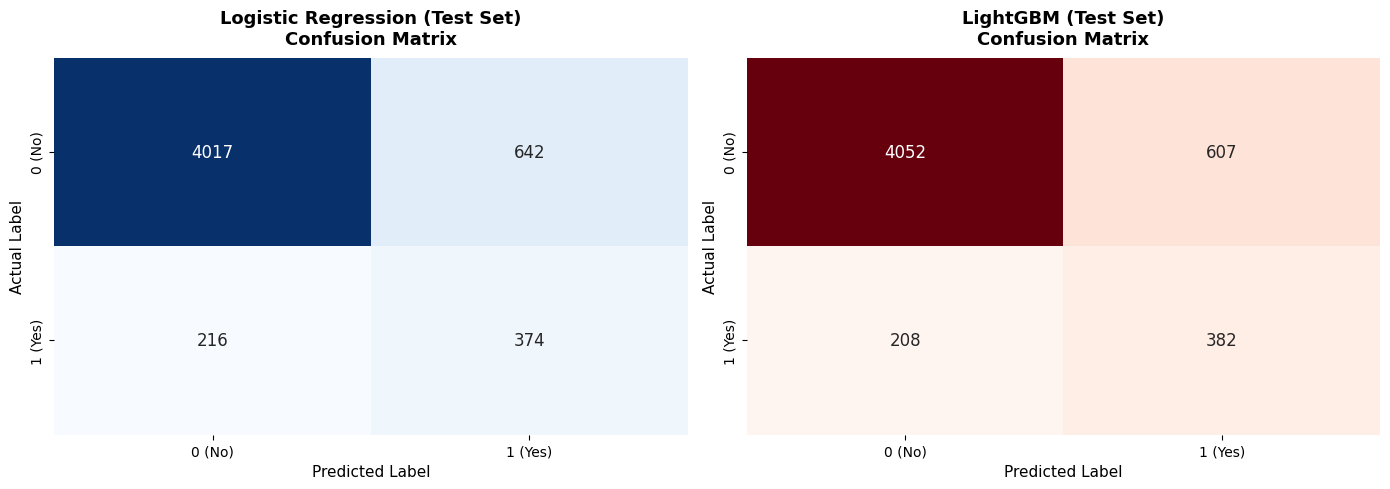

In [24]:
# ── 3. Visual Reality Check (Test Set Confusion Matrices) ────────────────────
cm_test_lr = confusion_matrix(y_test, y_test_pred_lr)
cm_test_lgb = confusion_matrix(y_test, y_test_pred_lgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR Matrix
sns.heatmap(cm_test_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            annot_kws={"size": 12}, cbar=False)
axes[0].set_title('Logistic Regression (Test Set)\nConfusion Matrix', fontsize=13, pad=10, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_xticklabels(['0 (No)', '1 (Yes)'])
axes[0].set_yticklabels(['0 (No)', '1 (Yes)'])

# XGBoost Matrix
sns.heatmap(cm_test_lgb, annot=True, fmt='d', cmap='Reds', ax=axes[1], 
            annot_kws={"size": 12}, cbar=False)
axes[1].set_title('LightGBM (Test Set)\nConfusion Matrix', fontsize=13, pad=10, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_xticklabels(['0 (No)', '1 (Yes)'])
axes[1].set_yticklabels(['0 (No)', '1 (Yes)'])

plt.tight_layout()
plt.savefig('test_set_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

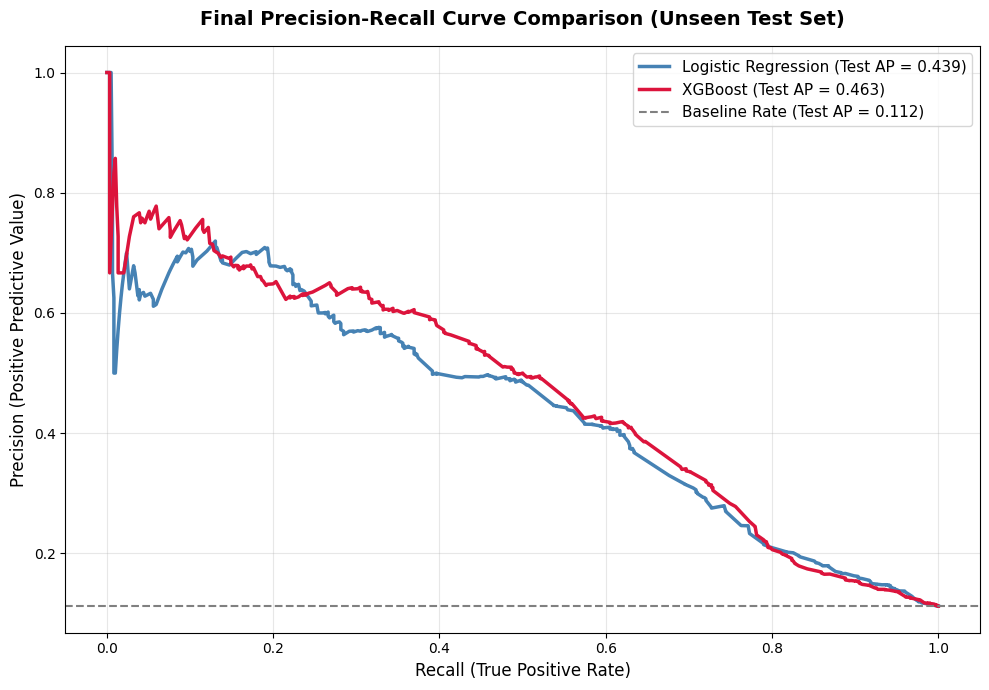

In [25]:
# =============================================================================
# FINAL VISUAL PROOF: TEST SET PR CURVE
# =============================================================================
plt.figure(figsize=(10, 7))

# Calculate PR curves using the Test Set predictions we generated earlier
precision_test_lr, recall_test_lr, _ = precision_recall_curve(y_test, y_test_prob_lr)
precision_test_lgb, recall_test_lgb, _ = precision_recall_curve(y_test, y_test_prob_lgb)

# Plot curves
plt.plot(recall_test_lr, precision_test_lr, color='steelblue', lw=2.5, 
         label=f'Logistic Regression (Test AP = {lr_test_aps:.3f})')
plt.plot(recall_test_lgb, precision_test_lgb, color='crimson', lw=2.5, 
         label=f'XGBoost (Test AP = {lgb_test_aps:.3f})')

# Plot Baseline Rate (Dataset Response Rate for the Test Set)
baseline_test_rate = y_test.mean()
plt.axhline(y=baseline_test_rate, color='gray', linestyle='--', 
            label=f'Baseline Rate (Test AP = {baseline_test_rate:.3f})')

# Formatting for the final presentation
plt.title('Final Precision-Recall Curve Comparison (Unseen Test Set)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and Show
plt.savefig('pr_curve_test_set_final.png', dpi=150, bbox_inches='tight')
plt.show()


── Logistic Regression Lift Table (Test Set) ───────────
 decile  total  events  event_rate     lift  cumulative_pct  cumulative_event_rate
      1    525     257    0.489524 4.355103       10.001905              43.559322
      2    525     120    0.228571 2.033511       20.003810              63.898305
      3    525      61    0.116190 1.033701       30.005715              74.237288
      4    525      22    0.041905 0.372810       40.007620              77.966102
      5    525      36    0.068571 0.610053       50.009526              84.067797
      6    524      29    0.055344 0.492370       59.992380              88.983051
      7    525      22    0.041905 0.372810       69.994285              92.711864
      8    525      19    0.036190 0.321973       79.996190              95.932203
      9    525       8    0.015238 0.135567       89.998095              97.288136
     10    525      16    0.030476 0.271135      100.000000             100.000000


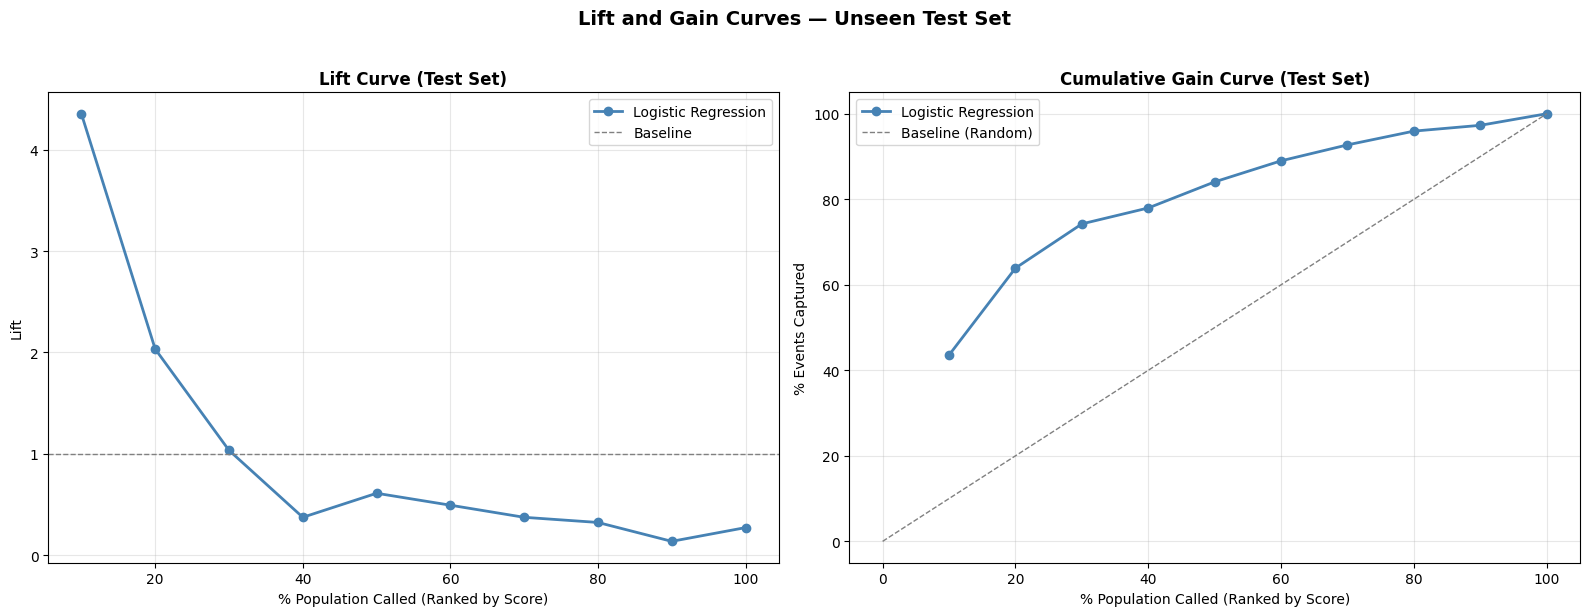

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Get predicted probabilities on UNSEEN TEST SET ─────────────────────────
y_test_proba_lr  = best_lr_model.predict_proba(X_test_final)[:, 1]
# y_test_proba_xgb = best_xgb.predict_proba(X_test_vif)[:, 1]

def compute_lift(y_true, y_proba, n_bins=10):
    df = pd.DataFrame({'y_true': y_true.values, 'y_proba': y_proba})
    df = df.sort_values('y_proba', ascending=False).reset_index(drop=True)
    
    df['decile'] = pd.qcut(df.index, q=n_bins, labels=False) + 1
    
    overall_rate = df['y_true'].mean()
    
    lift_df = (df.groupby('decile')
                 .agg(
                     total       = ('y_true', 'count'),
                     events      = ('y_true', 'sum'),
                     avg_proba   = ('y_proba', 'mean')
                 )
                 .reset_index())
    
    lift_df['event_rate']    = lift_df['events'] / lift_df['total']
    lift_df['lift']          = lift_df['event_rate'] / overall_rate
    lift_df['cumulative_pct']= lift_df['total'].cumsum() / lift_df['total'].sum() * 100
    lift_df['cumulative_events'] = lift_df['events'].cumsum()
    lift_df['cumulative_event_rate'] = (lift_df['cumulative_events'] / 
                                        lift_df['events'].sum() * 100)
    
    return lift_df

# ── 2. Compute lift tables for TEST SET ──────────────────────────────────────
lift_test_lr  = compute_lift(y_test, y_test_proba_lr)
# lift_test_xgb = compute_lift(y_test, y_test_proba_xgb)

print("\n── Logistic Regression Lift Table (Test Set) ───────────")
print(lift_test_lr[['decile', 'total', 'events', 'event_rate', 
                    'lift', 'cumulative_pct', 
                    'cumulative_event_rate']].to_string(index=False))


# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Lift curve
ax1 = axes[0]
ax1.plot(lift_test_lr['cumulative_pct'],  lift_test_lr['lift'],
         color='steelblue', linewidth=2, marker='o', label='Logistic Regression')
# ax1.plot(lift_test_xgb['cumulative_pct'], lift_test_xgb['lift'],
#          color='crimson',   linewidth=2, marker='o', label='XGBoost')
ax1.axhline(y=1, color='grey', linestyle='--', linewidth=1, label='Baseline')
ax1.set_xlabel('% Population Called (Ranked by Score)')
ax1.set_ylabel('Lift')
ax1.set_title('Lift Curve (Test Set)', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# -- Cumulative gain curve
ax2 = axes[1]
ax2.plot(lift_test_lr['cumulative_pct'],  lift_test_lr['cumulative_event_rate'],
         color='steelblue', linewidth=2, marker='o', label='Logistic Regression')
# ax2.plot(lift_test_xgb['cumulative_pct'], lift_test_xgb['cumulative_event_rate'],
#          color='crimson',   linewidth=2, marker='o', label='XGBoost')
ax2.plot([0, 100], [0, 100],
         color='grey', linestyle='--', linewidth=1, label='Baseline (Random)')
ax2.set_xlabel('% Population Called (Ranked by Score)')
ax2.set_ylabel('% Events Captured')
ax2.set_title('Cumulative Gain Curve (Test Set)', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Lift and Gain Curves — Unseen Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lift_gain_curves_test.png', dpi=150, bbox_inches='tight')
plt.show()

## The Lift-Gain curve both clearly showcase the fact that by targeting top 30% of the customers i am effectively capturing 75% of the responders, beyond which my lift drops to below 1.

Since you are only calling the top 30%, anyone in Deciles 1–3 is Predicted Positive (Called), and anyone in Deciles 4–10 is Predicted Negative (Not Called).

True Positives (TP): Events in the top 30% $\rightarrow$ $438$

False Positives (FP): Non-events in the top 30% $\rightarrow$ $\text{Total Called} - \text{TP} = 1,575 - 438 =$ $1,137$

False Negatives (FN): Events missed in the remaining 70% $\rightarrow$ $\text{Total Actual Events} - \text{TP} = 590 - 438 =$ $152$

True Negatives (TN): Non-events successfully avoided in the remaining 70% $\rightarrow$ $\text{Total Actual Negatives} - \text{FP} = 4,659 - 1,137 =$ $3,522$

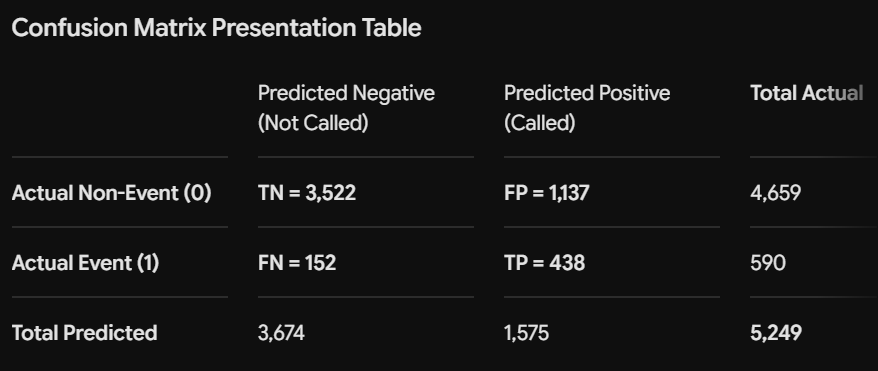


a) Expected net profit we stand to make by running this campaign on the customers we intent to phone?

In [31]:
# 1. Inputs
pop_pct_calls = 0.3
pop = 10000
conv_rate = 0.385  # (tp/(tp+fp))

pop_distribution = {'Low': 0.65, 'Medium': 0.25, 'High': 0.1}
profit_margins = {'Low': 1225.00, 'Medium': 705.00, 'High': 285.00}
rejection_penalty = -300.00 

# 2. Global Calculation
weighted_expected_profit = sum(pop_distribution[tier] * profit_margins[tier] for tier in pop_distribution)
net_profit1 = weighted_expected_profit
net_profit2 = rejection_penalty

expected_profit = pop * pop_pct_calls * (net_profit1 * conv_rate + net_profit2 * (1 - conv_rate))

print(f"=== GLOBAL METRICS ===")
print(f"Weighted Expected Profit Margin : ${weighted_expected_profit:,.2f}")
print(f"Net Profit Scenario 1 (Conv)   : ${net_profit1:,.2f}")
print(f"Net Profit Scenario 2 (Reject) : ${net_profit2:,.2f}")
print(f"Overall Campaign Expected Profit: ${expected_profit:,.2f}\n")

print(f"=== TIER BREAKDOWN METRICS ===")
total_tier_profit = 0
for tier in ['Low', 'Medium', 'High']:
    tier_pop = pop * pop_distribution[tier]
    tier_calls = tier_pop * pop_pct_calls
    np1_tier = profit_margins[tier]
    exp_profit_tier = tier_calls * (np1_tier * conv_rate + rejection_penalty * (1 - conv_rate))
    total_tier_profit += exp_profit_tier
    print(f"{tier:<7} Risk Tier Expected Profit: ${exp_profit_tier:,.2f}")

=== GLOBAL METRICS ===
Weighted Expected Profit Margin : $1,001.00
Net Profit Scenario 1 (Conv)   : $1,001.00
Net Profit Scenario 2 (Reject) : $-300.00
Overall Campaign Expected Profit: $602,655.00

=== TIER BREAKDOWN METRICS ===
Low     Risk Tier Expected Profit: $559,893.75
Medium  Risk Tier Expected Profit: $65,193.75
High    Risk Tier Expected Profit: $-22,432.50


b) What is the lost opportunity of net profit due to us misclassifying customers by using your response model?

In [37]:
pop = 10000
baseline_conversion_rate = 0.1123
missclassification_ratio = (152/(152+438)) #fn/(tp+fn)

pop_distribution = {'Low': 0.65, 'Medium': 0.25, 'High': 0.1}
profit_margins = {'Low': 1225.00, 'Medium': 705.00, 'High': 285.00}
rejection_penalty = -300.00 

# 2. Global Calculation
weighted_expected_profit = sum(pop_distribution[tier] * profit_margins[tier] for tier in pop_distribution)

opportunity_loss = pop*baseline_conversion_rate*missclassification_ratio*weighted_expected_profit

print(f"=== GLOBAL METRICS ===")
print(f"Weighted Expected Profit Margin : ${weighted_expected_profit:,.2f}")
print(f"Expected Total Buyer : {int(pop*baseline_conversion_rate)}")
print(f"Misclassified Buyer : {int(pop*baseline_conversion_rate*missclassification_ratio)}")
print(f"Misclassification rate : {(pop*baseline_conversion_rate*missclassification_ratio)/(pop*baseline_conversion_rate):,.2f}")
print(f"Overall Campaign Expected Opportunity Loss: ${opportunity_loss:,.2f}\n")

print(f"=== TIER BREAKDOWN METRICS ===")
total_tier_loss_opp = 0
for tier in ['Low', 'Medium', 'High']:
    tier_pop = pop * pop_distribution[tier]
    opp_loss_tier = tier_pop * profit_margins[tier] * baseline_conversion_rate * missclassification_ratio
    total_tier_loss_opp += opp_loss_tier
    print(f"{tier:<7} Risk Tier Expected Opportunity Loss: ${opp_loss_tier:,.2f}")

=== GLOBAL METRICS ===
Weighted Expected Profit Margin : $1,001.00
Expected Total Buyer : 1123
Misclassified Buyer : 289
Misclassification rate : 0.26
Overall Campaign Expected Opportunity Loss: $289,604.57

=== TIER BREAKDOWN METRICS ===
Low     Risk Tier Expected Opportunity Loss: $230,367.27
Medium  Risk Tier Expected Opportunity Loss: $50,991.81
High    Risk Tier Expected Opportunity Loss: $8,245.48
